# 07 - Machine Learning Model Training

### Objective

The goal of this notebook is to train machine learning classification models to predict the next trading day's stock price direction.

### Target

- **1** → Next day's closing price is higher
- **0** → Next day's closing price is lower or equal

### Workflow

1. Load ML-ready datasets
2. Select input features and target
3. Perform chronological train-test split
4. Scale features where required
5. Train baseline classification models
6. Generate predictions
7. Evaluate and compare model performance

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score

from mlxtend.plotting import plot_confusion_matrix

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
stocks = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS"
]

In [3]:
ml_data = {}

for stock in stocks:
    ml_data[stock] = pd.read_csv(
        f"../data/ml_ready/{stock}_ml.csv",
        parse_dates=['Date']
    )

In [4]:
for stock in stocks:

    print(
        stock,
        "→",
        ml_data[stock].shape
    )

AAPL → (2715, 24)
MSFT → (2715, 24)
NVDA → (2715, 24)
AMZN → (2715, 24)
RELIANCE.NS → (2664, 24)
TCS.NS → (2664, 24)
HDFCBANK.NS → (2664, 24)
INFY.NS → (2664, 24)


In [5]:
features = [
    "Daily_Return",
    
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    
    "SMA_5",
    "SMA_20",
    "SMA_50",
    
    "EMA_20",
    
    "Volatility_20",
    "Volume_Change",
    
    "High_Low_Range",
    "Open_Close_Change",
    
    "RSI_14",
    
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

target = "Target"

In [6]:
X = {}
y = {}

for stock in stocks:
    
    X[stock] = ml_data[stock][features]
    
    y[stock] = ml_data[stock][target]

## Chronological Train-Test Split

Since stock market data is time-dependent, the dataset should not be randomly shuffled before splitting.

A chronological split is used where:

- The first **80%** of observations are used for training.
- The remaining **20%** are used for testing.

This ensures that the model learns from historical data and is evaluated on future unseen data, which better represents a real-world prediction scenario.

In [7]:
X_train = {}
X_test = {}

y_train = {}
y_test = {}


for stock in stocks:
    
    split_idx = int(len(X[stock]) * 0.8)
    
    X_train[stock] = X[stock].iloc[:split_idx]
    X_test[stock] = X[stock].iloc[split_idx:]
    
    y_train[stock] = y[stock].iloc[:split_idx]
    y_test[stock] = y[stock].iloc[split_idx:]

### Verify Train-Test Distribution

The size of the training and testing datasets is checked for each stock to ensure that the chronological 80-20 split was performed correctly.

In [8]:
for stock in stocks:

    print(
        stock,
        "| Train:",
        X_train[stock].shape,
        "| Test:",
        X_test[stock].shape
    )

AAPL | Train: (2172, 16) | Test: (543, 16)
MSFT | Train: (2172, 16) | Test: (543, 16)
NVDA | Train: (2172, 16) | Test: (543, 16)
AMZN | Train: (2172, 16) | Test: (543, 16)
RELIANCE.NS | Train: (2131, 16) | Test: (533, 16)
TCS.NS | Train: (2131, 16) | Test: (533, 16)
HDFCBANK.NS | Train: (2131, 16) | Test: (533, 16)
INFY.NS | Train: (2131, 16) | Test: (533, 16)


### Verify Chronological Order

The date ranges of the training and testing sets are inspected to confirm that the training data contains earlier observations and the testing data contains later observations.

This helps prevent future information from being used during model training.

In [9]:
for stock in stocks:

    split_index = len(X_train[stock])

    df = ml_data[stock]

    print(f"\n{stock}")

    print(
        "Train:",
        df["Date"].iloc[0].date(),
        "to",
        df["Date"].iloc[split_index - 1].date()
    )

    print(
        "Test :",
        df["Date"].iloc[split_index].date(),
        "to",
        df["Date"].iloc[-1].date()
    )


AAPL
Train: 2015-03-16 to 2023-10-27
Test : 2023-10-30 to 2025-12-29

MSFT
Train: 2015-03-16 to 2023-10-27
Test : 2023-10-30 to 2025-12-29

NVDA
Train: 2015-03-16 to 2023-10-27
Test : 2023-10-30 to 2025-12-29

AMZN
Train: 2015-03-16 to 2023-10-27
Test : 2023-10-30 to 2025-12-29

RELIANCE.NS
Train: 2015-03-16 to 2023-10-30
Test : 2023-10-31 to 2025-12-29

TCS.NS
Train: 2015-03-16 to 2023-10-30
Test : 2023-10-31 to 2025-12-29

HDFCBANK.NS
Train: 2015-03-16 to 2023-10-30
Test : 2023-10-31 to 2025-12-29

INFY.NS
Train: 2015-03-16 to 2023-10-30
Test : 2023-10-31 to 2025-12-29


## Logistic Regression Pipeline

The engineered features have different numerical ranges — RSI, moving averages, returns, and volatility are all measured on different scales. `StandardScaler` is used to standardize the features before training Logistic Regression.

To avoid data leakage and keep scaling + training tied together, an `sklearn` `Pipeline` is used:

- The pipeline combines `StandardScaler` and `LogisticRegression` into a single object.
- Calling `.fit()` fits the scaler on the training data only, then trains the model on the scaled result.
- Calling `.predict()` automatically transforms new data using the *already-fitted* scaler (not refit), so the test set is never used to influence scaling.
- A separate pipeline is trained for each stock.

The model predicts the next trading day's stock price direction:

- **1** → Next-day closing price increases
- **0** → Next-day closing price decreases or remains unchanged

After training, each pipeline predicts the target class for its corresponding unseen test dataset. These predictions will later be compared with the actual target values to evaluate model performance.

In [ ]:
models = {}
predictions = {}

for stock in stocks:
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=100))
    ])
    
    pipeline.fit(X_train[stock], y_train[stock])
    
    predictions[stock] = pipeline.predict(X_test[stock])
    
    
    print(f"{stock} model trained successfully.")

AAPL model trained successfully.
MSFT model trained successfully.
NVDA model trained successfully.
AMZN model trained successfully.
RELIANCE.NS model trained successfully.
TCS.NS model trained successfully.
HDFCBANK.NS model trained successfully.
INFY.NS model trained successfully.


In [11]:
predictions["AAPL"][:20]

array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model Evaluation

The trained Logistic Regression models are evaluated on the unseen test datasets.

The following classification metrics are used:

- **Accuracy** – Percentage of total predictions that are correct.
- **Precision** – Among the days predicted as UP, how many were actually UP.
- **Recall** – Among the actual UP days, how many were correctly identified.
- **F1-Score** – Harmonic mean of precision and recall.

The metrics are calculated separately for each stock to compare model performance across companies.

In [12]:
results = []

for stock in stocks:
    
    y_true = y_test[stock]
    y_pred = predictions[stock]
    
    results.append({
        "Stock" : stock,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision" : precision_score(y_true, y_pred, zero_division=0),
        "Recall" : recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    })
    
result_df = pd.DataFrame(results)

result_df

,Stock,Accuracy,Precision,Recall,F1-Score
0,AAPL,0.495396,0.533333,0.619529,0.573209
1,MSFT,0.497238,0.540717,0.557047,0.548760
2,NVDA,0.475138,0.758621,0.073333,0.133739
3,AMZN,0.502762,0.545918,0.371528,0.442149
4,RELIANCE.NS,0.491557,0.513514,0.544803,0.528696
5,TCS.NS,0.459662,0.450000,0.725806,0.555556
6,HDFCBANK.NS,0.480300,0.505952,0.604982,0.551053
7,INFY.NS,0.510319,0.504484,0.849057,0.632911


In [13]:
for stock in stocks:

    print(f"\n{stock}")

    print(
        pd.Series(predictions[stock])
        .value_counts()
    )


AAPL
1    345
0    198
Name: count, dtype: int64

MSFT
1    307
0    236
Name: count, dtype: int64

NVDA
0    514
1     29
Name: count, dtype: int64

AMZN
0    347
1    196
Name: count, dtype: int64

RELIANCE.NS
1    296
0    237
Name: count, dtype: int64

TCS.NS
1    400
0    133
Name: count, dtype: int64

HDFCBANK.NS
1    336
0    197
Name: count, dtype: int64

INFY.NS
1    446
0     87
Name: count, dtype: int64


In [14]:
for stock in stocks:

    print(f"\n{stock}")

    print(
        y_test[stock]
        .value_counts()
    )


AAPL
Target
1    297
0    246
Name: count, dtype: int64

MSFT
Target
1    298
0    245
Name: count, dtype: int64

NVDA
Target
1    300
0    243
Name: count, dtype: int64

AMZN
Target
1    288
0    255
Name: count, dtype: int64

RELIANCE.NS
Target
1    279
0    254
Name: count, dtype: int64

TCS.NS
Target
0    285
1    248
Name: count, dtype: int64

HDFCBANK.NS
Target
1    281
0    252
Name: count, dtype: int64

INFY.NS
Target
0    268
1    265
Name: count, dtype: int64


## Confusion Matrix

The confusion matrix provides a detailed comparison between the actual and predicted stock movement classes.

- **True Negative (TN)** → Correctly predicted DOWN
- **False Positive (FP)** → Predicted UP, but actually DOWN
- **False Negative (FN)** → Predicted DOWN, but actually UP
- **True Positive (TP)** → Correctly predicted UP

The confusion matrices are visualized using `mlxtend` for easier interpretation of classification performance.

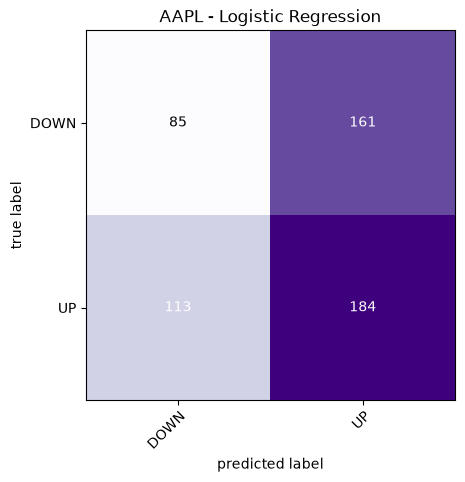

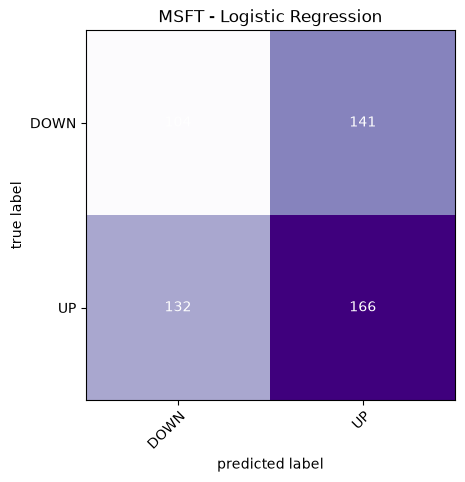

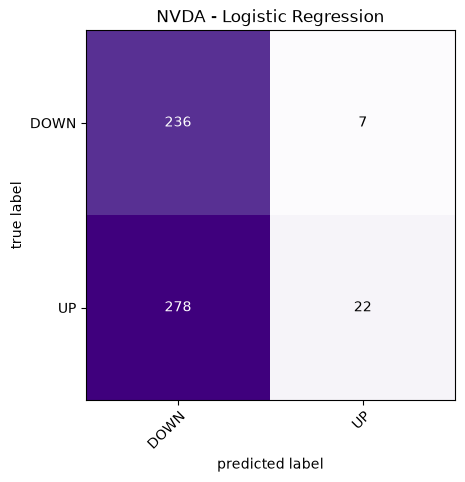

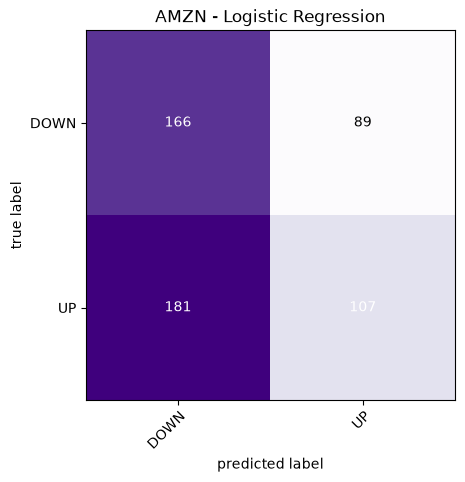

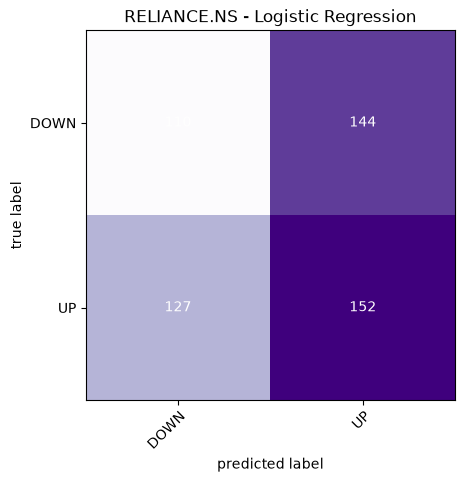

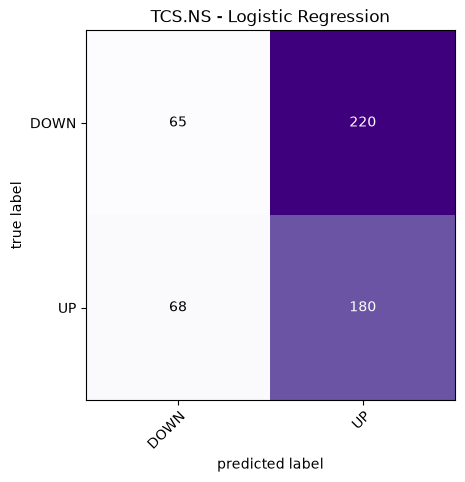

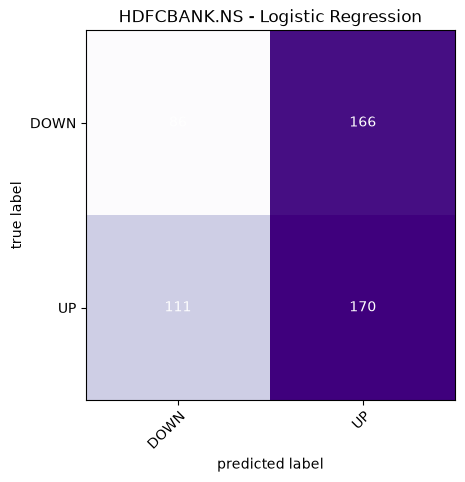

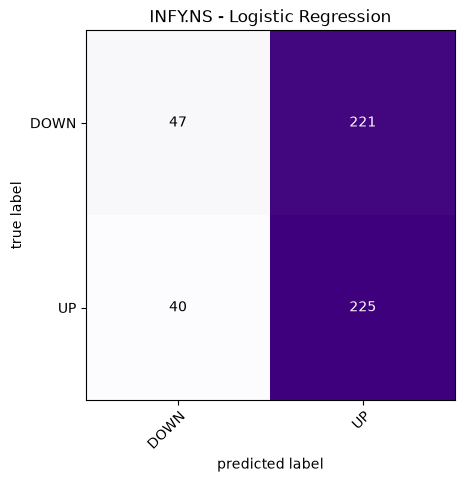

In [ ]:
for stock in stocks:
    
    y_true = y_test[stock]
    y_pred = predictions[stock]
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plot_confusion_matrix(cm, class_names=["DOWN", "UP"], cmap='Purples')
    ax.set_title(f"{stock} - Logistic Regression")
    
    plt.show()

## Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make predictions.

Unlike Logistic Regression, Random Forest can capture complex and non-linear relationships between stock market features.

A separate Random Forest model is trained for each stock using the same chronological training and testing datasets.

### Why Random Forest?

- Captures non-linear relationships between features and target.
- Combines multiple decision trees to reduce overfitting.
- Works well with multiple technical indicators and numerical features.
- Provides feature importance scores that help identify influential predictors.

In [16]:
rf_models = {}

for stock in stocks:
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    rf_model.fit(X_train[stock], y_train[stock])
    
    rf_models[stock] = rf_model
    
    print(f"{stock} Random Forest trained successfully.")
    

AAPL Random Forest trained successfully.
MSFT Random Forest trained successfully.
NVDA Random Forest trained successfully.
AMZN Random Forest trained successfully.
RELIANCE.NS Random Forest trained successfully.
TCS.NS Random Forest trained successfully.
HDFCBANK.NS Random Forest trained successfully.
INFY.NS Random Forest trained successfully.


## Random Forest Predictions

The trained Random Forest models are used to predict next-day stock price direction on the unseen test datasets.

Since Random Forest is a tree-based algorithm, the original unscaled features are used for prediction.

In [17]:
rf_predictions = {}

for stock in stocks:
    
    rf_predictions[stock] = rf_models[stock].predict(X_test[stock])

## Random Forest Model Evaluation

The Random Forest models are evaluated using the same classification metrics used for Logistic Regression:

- Accuracy
- Precision
- Recall
- F1-Score

Using identical evaluation metrics allows a fair comparison between the two classification models.

In [18]:
rf_results = []

for stock in stocks:
    
    y_true = y_test[stock]
    y_pred = rf_predictions[stock]
    
    rf_results.append({
        "Stock" : stock,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision" : precision_score(y_true, y_pred, zero_division=0),
        "Recall" : recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    })
    
rf_result_df = pd.DataFrame(rf_results)
    
rf_result_df

,Stock,Accuracy,Precision,Recall,F1-Score
0,AAPL,0.484346,0.548571,0.323232,0.406780
1,MSFT,0.462247,0.525862,0.204698,0.294686
2,NVDA,0.510129,0.641667,0.256667,0.366667
3,AMZN,0.486188,0.528662,0.288194,0.373034
4,RELIANCE.NS,0.521576,0.585714,0.293907,0.391408
5,TCS.NS,0.542214,0.514085,0.294355,0.374359
6,HDFCBANK.NS,0.469043,0.491071,0.195730,0.279898
7,INFY.NS,0.495310,0.489130,0.339623,0.400891


## Random Forest Confusion Matrix

Confusion matrices are used to visualize the classification performance of the Random Forest models.

They show the number of correctly and incorrectly predicted UP and DOWN movements for each stock.

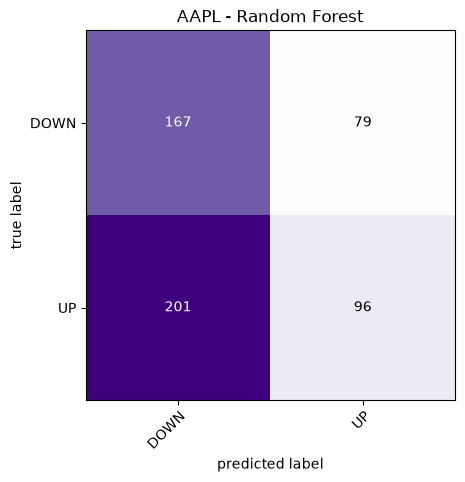

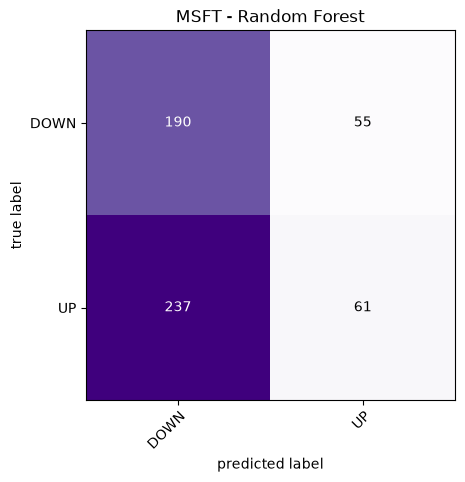

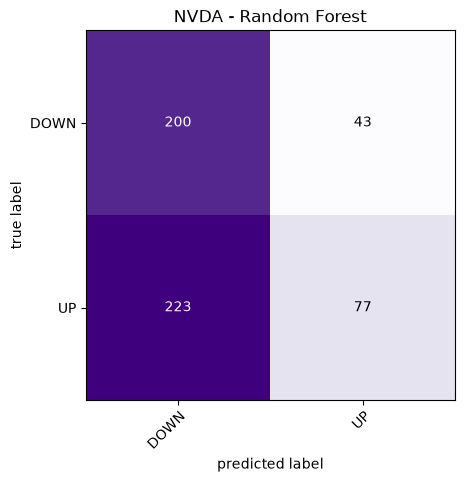

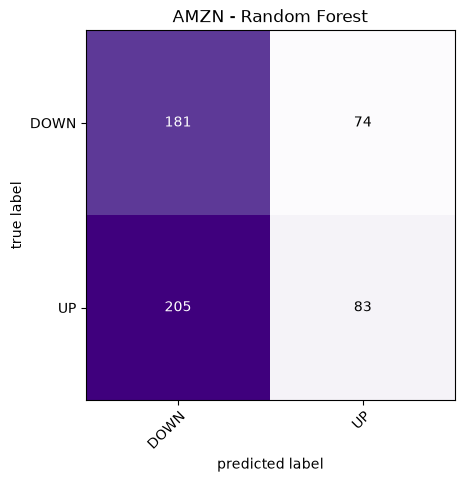

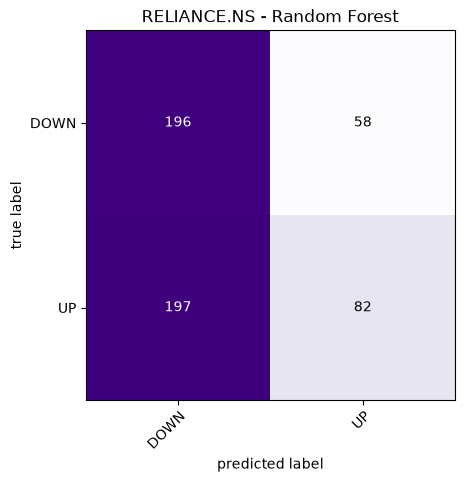

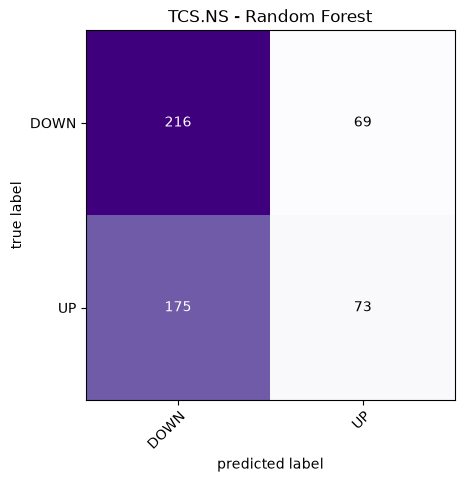

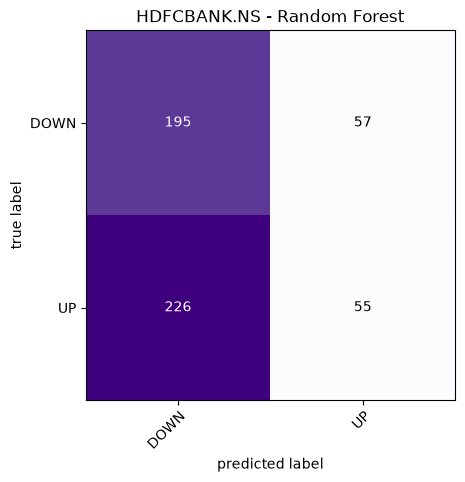

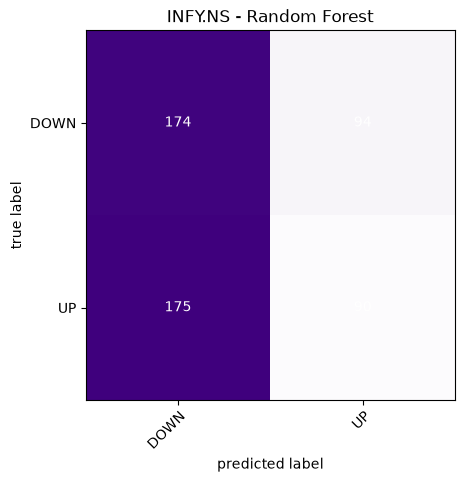

In [19]:
for stock in stocks:
    
    y_true = y_test[stock]
    y_pred = rf_predictions[stock]
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plot_confusion_matrix(cm, class_names=["DOWN", "UP"], cmap='Purples')
    ax.set_title(f"{stock} - Random Forest")
    
    plt.show()

## Model Performance Comparison

The performance of Logistic Regression and Random Forest is compared across all stocks using Accuracy, Precision, Recall, and F1-Score.

This comparison helps determine which model performs better for each stock and whether a more complex ensemble model provides an improvement over the simpler Logistic Regression model.

In [20]:
comparison_df = result_df.merge(
    rf_result_df,
    on="Stock",
    suffixes=("_Logistic", "_RandomForest")
)

comparison_df

,Stock,Accuracy_Logistic,Precision_Logistic,Recall_Logistic,F1-Score_Logistic,Accuracy_RandomForest,Precision_RandomForest,Recall_RandomForest,F1-Score_RandomForest
0,AAPL,0.495396,0.533333,0.619529,0.573209,0.484346,0.548571,0.323232,0.406780
1,MSFT,0.497238,0.540717,0.557047,0.548760,0.462247,0.525862,0.204698,0.294686
2,NVDA,0.475138,0.758621,0.073333,0.133739,0.510129,0.641667,0.256667,0.366667
3,AMZN,0.502762,0.545918,0.371528,0.442149,0.486188,0.528662,0.288194,0.373034
4,RELIANCE.NS,0.491557,0.513514,0.544803,0.528696,0.521576,0.585714,0.293907,0.391408
5,TCS.NS,0.459662,0.450000,0.725806,0.555556,0.542214,0.514085,0.294355,0.374359
6,HDFCBANK.NS,0.480300,0.505952,0.604982,0.551053,0.469043,0.491071,0.195730,0.279898
7,INFY.NS,0.510319,0.504484,0.849057,0.632911,0.495310,0.489130,0.339623,0.400891


In [21]:
comparison_df["Best_Model"] = np.where(
    comparison_df["Accuracy_Logistic"] >
    comparison_df["Accuracy_RandomForest"],
    "Logistic Regression",
    "Random Forest"
)

comparison_df

,Stock,Accuracy_Logistic,Precision_Logistic,Recall_Logistic,F1-Score_Logistic,Accuracy_RandomForest,Precision_RandomForest,Recall_RandomForest,F1-Score_RandomForest,Best_Model
0,AAPL,0.495396,0.533333,0.619529,0.573209,0.484346,0.548571,0.323232,0.406780,Logistic Regression
1,MSFT,0.497238,0.540717,0.557047,0.548760,0.462247,0.525862,0.204698,0.294686,Logistic Regression
2,NVDA,0.475138,0.758621,0.073333,0.133739,0.510129,0.641667,0.256667,0.366667,Random Forest
3,AMZN,0.502762,0.545918,0.371528,0.442149,0.486188,0.528662,0.288194,0.373034,Logistic Regression
4,RELIANCE.NS,0.491557,0.513514,0.544803,0.528696,0.521576,0.585714,0.293907,0.391408,Random Forest
5,TCS.NS,0.459662,0.450000,0.725806,0.555556,0.542214,0.514085,0.294355,0.374359,Random Forest
6,HDFCBANK.NS,0.480300,0.505952,0.604982,0.551053,0.469043,0.491071,0.195730,0.279898,Logistic Regression
7,INFY.NS,0.510319,0.504484,0.849057,0.632911,0.495310,0.489130,0.339623,0.400891,Logistic Regression


In [ ]:
Path("../results").mkdir(parents=True, exist_ok=True)

result_df.to_csv(
    "../results/logistic_results.csv",
    index=False
)

rf_result_df.to_csv(
    "../results/default_rf_results.csv",
    index=False
)

## Conclusion

Logistic Regression and Random Forest were successfully trained and evaluated across all eight stocks using chronological train-test splitting.

The results show that model performance varies across stocks, with no single model consistently performing best for every company.

The evaluation results are saved for later comparison and final model selection in StockVision.